In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve

In [5]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Basic EDA

Shape of Dataset: (1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
Info of Dataset: 
None
Null Values Count: age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope

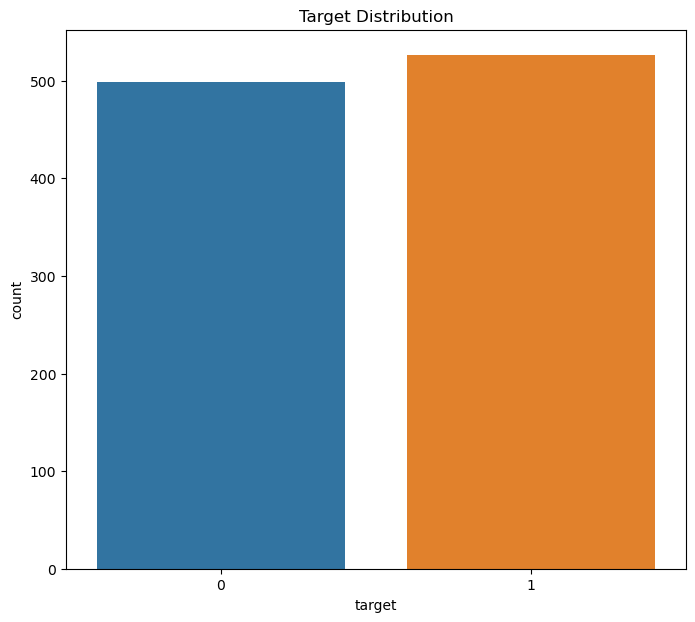

Correlation Between Features: 



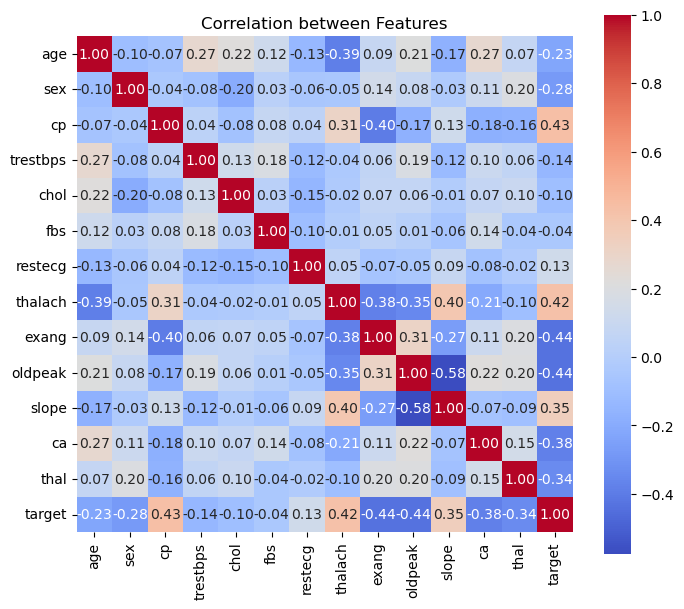

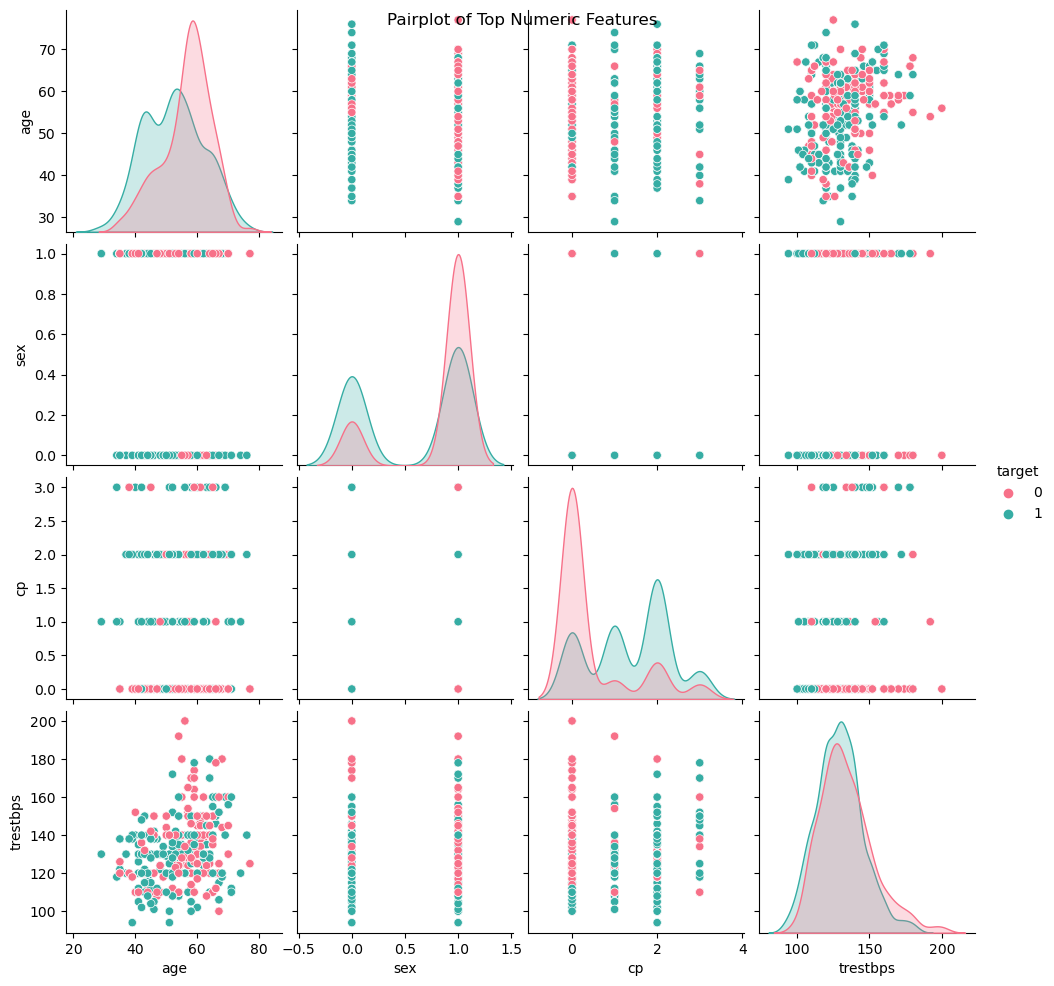

In [8]:
def basic_eda(df, target_col):
    print(f"Shape of Dataset: {df.shape}")

    print(f"Info of Dataset: \n{df.info()}")

    print(f"Null Values Count: {df.isnull().sum()}")

    print(f"Duplicate Values Count: {df.duplicated().sum()}")

    print(f"Target Value Distribution: \n {df[target_col].nunique()}")
    plt.figure(figsize = (8, 7))
    sns.countplot(x = target_col, data = df)
    plt.title(f"Target Distribution")
    plt.show()

    print(f"Correlation Between Features: \n")
    plt.figure(figsize = (8, 7))
    sns.heatmap(df.corr(), annot = True, fmt = ".2f", cmap = "coolwarm", square = True)
    plt.title(f"Correlation between Features")
    plt.show()

    numeric_cols = df.drop(columns = target_col).select_dtypes(include = [np.number]).columns.tolist()
    top_num = numeric_cols[:4]

    if len(top_num) > 1:
        sns.pairplot(df[top_num + [target_col]], hue = target_col, palette = "husl")
        plt.suptitle("Pairplot of Top Numeric Features")
        plt.show()

basic_eda(df, target_col = 'target')

In [11]:
def build_preprocessing_pipeline(df, target_col):
    df = df.drop_duplicates()

    X = df.drop(columns = [target_col])
    y = df[target_col]

    numeric_features = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()

    numeric_pipe = Pipeline(steps = [
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
    ])

    preprocessor = ColumnTransformer(transformers = [
        ('num', numeric_pipe, numeric_features)
    ])

    return X, y, preprocessor

X, y, preprocessor = build_preprocessing_pipeline(df, target_col = 'target')

In [20]:
def classification_model(X_train, y_train, preprocessor):
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier())
    ])

    # CORRECTED: Changed to K-Nearest Neighbor hyperparameters
    param_grid = {
        'classifier__n_neighbors': [3, 5, 7, 9, 11],
        'classifier__weights': ['uniform', 'distance'],
        'classifier__p': [1, 2] # 1 = Manhattan, 2 = Euclidean
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        estimator=full_pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)

    print(f"Best Hyperparameters: {grid_search.best_params_}")
    print(f"Best CV Score (Weighted F1): {grid_search.best_score_:.4f}")

    return grid_search.best_estimator_

# Assuming X, y, and preprocessor are defined earlier in your script
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model = classification_model(X_train, y_train, preprocessor)

Best Hyperparameters: {'classifier__n_neighbors': 9, 'classifier__p': 1, 'classifier__weights': 'uniform'}
Best CV Score (Weighted F1): 0.8281


Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.69      0.79        32
           1       0.73      0.93      0.82        29

    accuracy                           0.80        61
   macro avg       0.82      0.81      0.80        61
weighted avg       0.83      0.80      0.80        61

Summary Metrics: 
               Metric    Value
            Accuracy 0.803279
Precision (Weighted) 0.729730
   Recall (Weighted) 0.931034
            F1-Score 0.818182
             ROC-AUC 0.809267


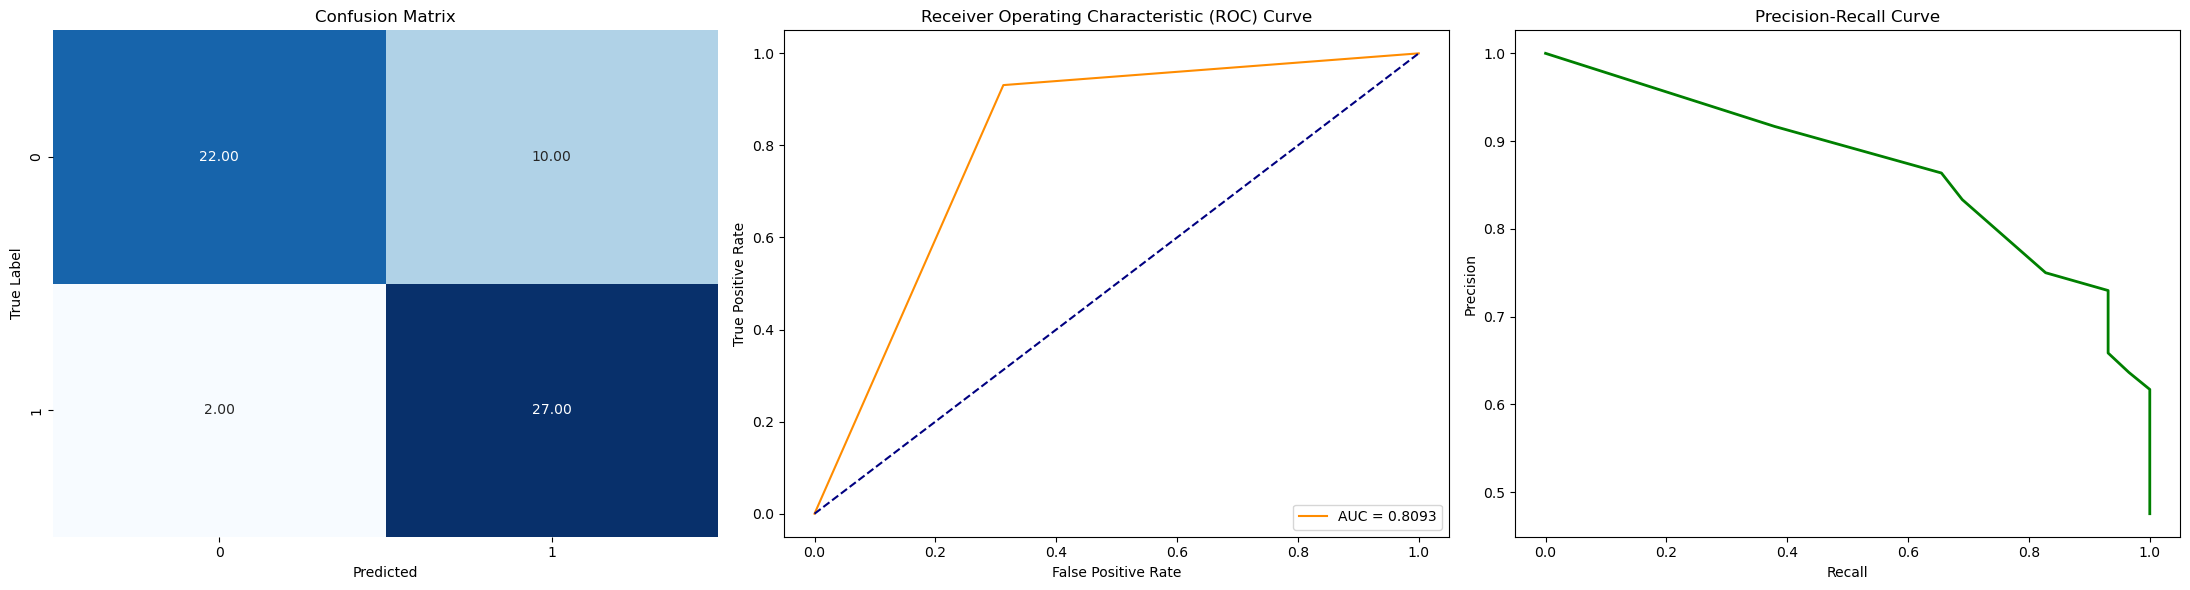

In [23]:
def evaluate_classification_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"Classification Report: \n {classification_report(y_test, y_pred)}")

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Weighted)': precision_score(y_test, y_pred),
        'Recall (Weighted)': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

    if y_prob is not None:
        metrics['ROC-AUC'] = roc_auc_score(y_test, y_pred)

    metrics_df = pd.DataFrame(list(metrics.items()), columns = ['Metric', 'Value'])
    print(f"Summary Metrics: \n {metrics_df.to_string(index = False)}")

    fig, axes = plt.subplots(1, 3, figsize = (22, 6))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot = True, fmt = ".2f", cmap = "Blues", ax = axes[0], cbar = False)
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True Label')

    if y_prob is not None:

        fpr, tpr, threshold = roc_curve(y_test, y_pred)
        axes[1].plot(fpr, tpr, label = f"AUC = {metrics['ROC-AUC']:.4f}", color = 'darkorange')
        axes[1].plot([0, 1], [0, 1], color = 'navy', linestyle = '--')
        axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].legend(loc = "lower right")

        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        axes[2].plot(recall, precision, color = 'green', lw = 2)
        axes[2].set_title('Precision-Recall Curve')
        axes[2].set_xlabel('Recall')
        axes[2].set_ylabel('Precision')

    else:
        axes[1].test(0.5, 0.5, 'Probabilities not available\nfor ROC curve', ha = 'center', va = 'center')
        axes[2].text(0.5, 0.5, 'Probabilities not available/nfor PR curve', ha = 'center', va = 'center')

    plt.tight_layout()
    plt.show()

evaluate_classification_model(best_model, X_test, y_test)

In [24]:
def test_random_dataset_samples(model, X_test, y_test, num_samples=3):
    print(f"--- TESTING {num_samples} RANDOM SAMPLES FROM DATASET ---\n")
    
    sample_indices = np.random.choice(X_test.index, size=num_samples, replace=False)
    
    X_samples = X_test.loc[sample_indices]
    y_true = y_test.loc[sample_indices]
    
    y_pred = model.predict(X_samples)
    y_prob = model.predict_proba(X_samples) if hasattr(model, "predict_proba") else None
    
    for i, (idx, row) in enumerate(X_samples.iterrows()):
        print(f"Sample {i+1} (Original Index: {idx})")
        print(f"Features:\n{row.to_dict()}")
        print(f"True Label:      {y_true.loc[idx]}")
        print(f"Predicted Label: {y_pred[i]}")
        
        if y_prob is not None:
            classes = model.classes_
            prob_dict = {str(classes[j]): round(y_prob[i][j], 4) for j in range(len(classes))}
            print(f"Probabilities:   {prob_dict}")
        print("-" * 50)

test_random_dataset_samples(best_model, X_test, y_test, num_samples=3)

--- TESTING 3 RANDOM SAMPLES FROM DATASET ---

Sample 1 (Original Index: 117)
Features:
{'age': 43.0, 'sex': 1.0, 'cp': 0.0, 'trestbps': 120.0, 'chol': 177.0, 'fbs': 0.0, 'restecg': 0.0, 'thalach': 120.0, 'exang': 1.0, 'oldpeak': 2.5, 'slope': 1.0, 'ca': 0.0, 'thal': 3.0}
True Label:      0
Predicted Label: 0
Probabilities:   {'0': 0.8889, '1': 0.1111}
--------------------------------------------------
Sample 2 (Original Index: 95)
Features:
{'age': 45.0, 'sex': 0.0, 'cp': 0.0, 'trestbps': 138.0, 'chol': 236.0, 'fbs': 0.0, 'restecg': 0.0, 'thalach': 152.0, 'exang': 1.0, 'oldpeak': 0.2, 'slope': 1.0, 'ca': 0.0, 'thal': 2.0}
True Label:      1
Predicted Label: 1
Probabilities:   {'0': 0.3333, '1': 0.6667}
--------------------------------------------------
Sample 3 (Original Index: 429)
Features:
{'age': 47.0, 'sex': 1.0, 'cp': 2.0, 'trestbps': 108.0, 'chol': 243.0, 'fbs': 0.0, 'restecg': 1.0, 'thalach': 152.0, 'exang': 0.0, 'oldpeak': 0.0, 'slope': 2.0, 'ca': 0.0, 'thal': 2.0}
True Label